<a href="https://colab.research.google.com/github/duttaaritra794-design/ARITRA_DUTTA/blob/main/RL_ENHANCED_AI_MPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BEST RL POLICY
Fn2  = 1
Fo2  = 0.5
P    = 0.85
R    = 3.60
Final Purity = 99.929%
Best Reward  = 30.109


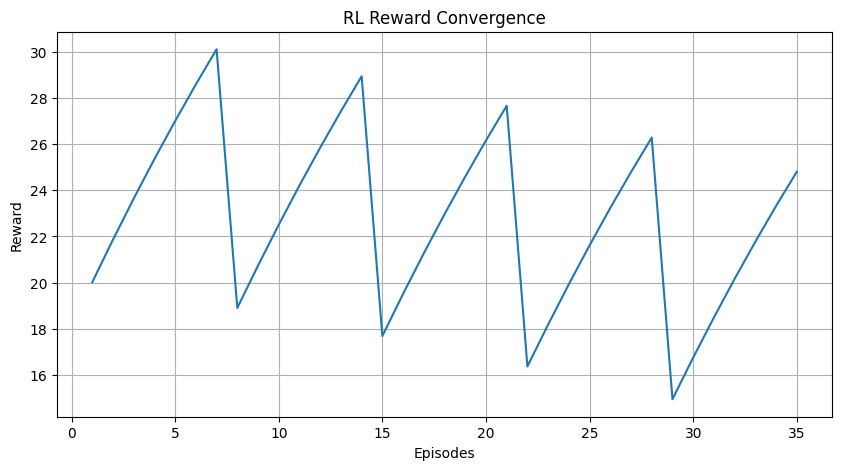

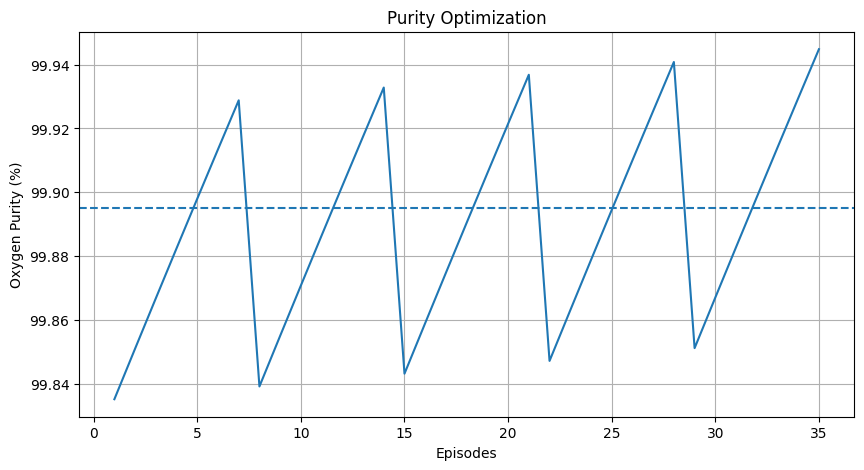

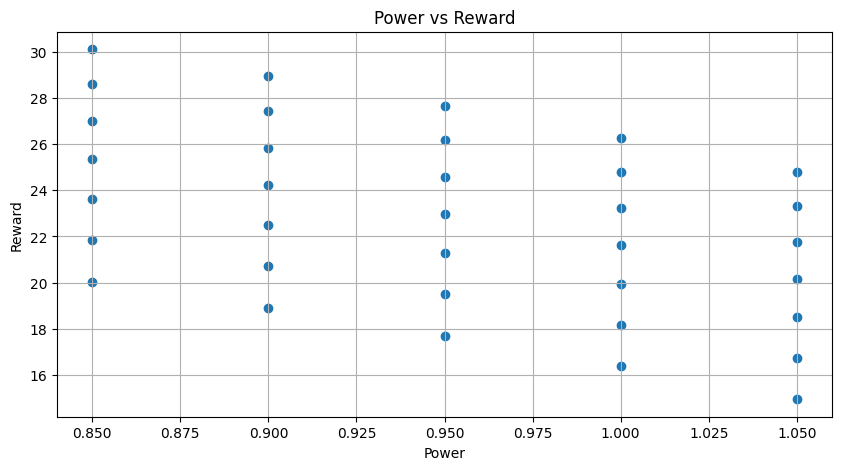

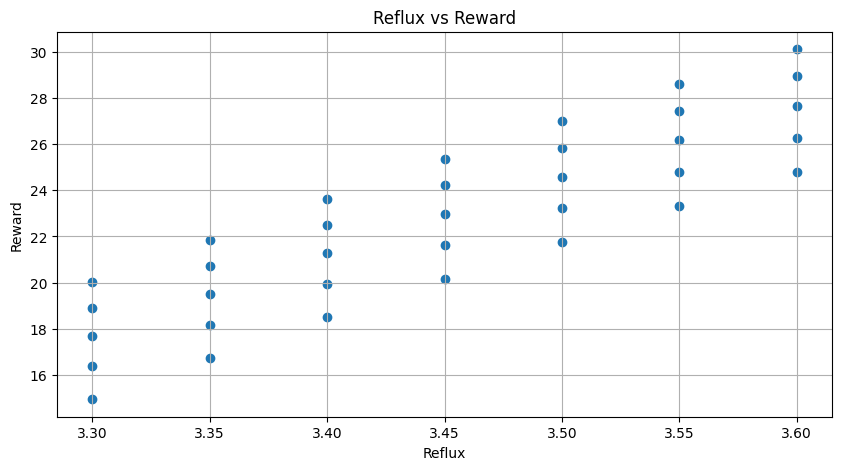

In [2]:

# RL-Enhanced AI-MPC Simulation for Cryogenic ASU
# Oxygen Purity Optimization using Moderate Reward Shaping

import numpy as np
import matplotlib.pyplot as plt

# INITIAL CONDITIONS

initial_purity = 97.8
target_purity = 99.895

# Lists for plotting
episodes = []
purities = []
rewards = []
powers = []
refluxes = []

# AI-ENHANCED MPC EQUATION

def calculate_purity(y, Fn2, Fo2, P, R):

    purity = (
        y
        + 0.25 * Fn2
        + 0.15 * Fo2
        + 0.08 * P
        + 0.45 * R
        - 0.06 * (Fn2 ** 2)
        - 0.04 * (Fo2 ** 2)
        - 0.02 * (R ** 2)
    )

    return purity

# RL REWARD FUNCTION
# Moderate Reward Shaping

def calculate_reward(y, target, Fn2, Fo2, P, R):

    # Purity reward
    purity_reward = 150 * (y - target)

    # Purity error penalty
    purity_penalty = -80 * ((target - y) ** 2)

    # Stability reward
    stability_reward = 20 - (
        8 * (Fn2 ** 2)
        + 6 * (Fo2 ** 2)
    )

    # Power reward
    power_reward = 40 - 20 * (P ** 2)

    # Reflux reward
    reflux_reward = 15 - 2 * (R ** 2)

    total_reward = (
        purity_reward
        + purity_penalty
        + stability_reward
        + power_reward
        + reflux_reward
    )

    return total_reward

# RL POLICY SEARCH

best_reward = -9999
best_policy = None
best_purity = None

episode = 0

# RL tries different combinations
for P in np.arange(0.85, 1.05, 0.05):

    for R in np.arange(3.3, 3.6, 0.05):

        episode += 1

        # Fixed safe operating values
        Fn2 = 1
        Fo2 = 0.5

        # STEP 1

        y1 = (
            initial_purity
            + 0.25 * Fn2
            - 0.06 * (Fn2 ** 2)
        )

        # STEP 2

        y2 = (
            y1
            + 0.25 * Fn2
            + 0.15 * Fo2
            - 0.06 * (Fn2 ** 2)
            - 0.04 * (Fo2 ** 2)
        )

        # STEP 3

        y3 = calculate_purity(y2, Fn2, Fo2, P, R)

        # REWARD

        reward = calculate_reward(
            y3,
            target_purity,
            Fn2,
            Fo2,
            P,
            R
        )

        # Store for graph
        episodes.append(episode)
        purities.append(y3)
        rewards.append(reward)
        powers.append(P)
        refluxes.append(R)

        # BEST POLICY CHECK

        if reward > best_reward:

            best_reward = reward
            best_policy = (Fn2, Fo2, P, R)
            best_purity = y3

# RESULTS

print("================================================")
print("BEST RL POLICY")
print("================================================")

print(f"Fn2  = {best_policy[0]}")
print(f"Fo2  = {best_policy[1]}")
print(f"P    = {best_policy[2]:.2f}")
print(f"R    = {best_policy[3]:.2f}")

print("================================================")

print(f"Final Purity = {best_purity:.3f}%")

print(f"Best Reward  = {best_reward:.3f}")

print("================================================")

# PLOT 1 — REWARD CONVERGENCE

plt.figure(figsize=(10, 5))

plt.plot(episodes, rewards)

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("RL Reward Convergence")

plt.grid(True)

plt.show()

# PLOT 2 — PURITY EVOLUTION

plt.figure(figsize=(10, 5))

plt.plot(episodes, purities)

plt.axhline(
    y=target_purity,
    linestyle='--'
)

plt.xlabel("Episodes")
plt.ylabel("Oxygen Purity (%)")
plt.title("Purity Optimization")

plt.grid(True)

plt.show()

# PLOT 3 — POWER VS REWARD

plt.figure(figsize=(10, 5))

plt.scatter(powers, rewards)

plt.xlabel("Power")
plt.ylabel("Reward")
plt.title("Power vs Reward")

plt.grid(True)

plt.show()

# PLOT 4 — REFLUX VS REWARD

plt.figure(figsize=(10, 5))

plt.scatter(refluxes, rewards)

plt.xlabel("Reflux")
plt.ylabel("Reward")
plt.title("Reflux vs Reward")

plt.grid(True)

plt.show()